In [62]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv("results/single_var/data.csv")
print(df.columns)
print("shape",df.shape)

Index(['p', 'D', 'seed', 'DX', 'D_diff', 'time', 'abs_theta'], dtype='object')
shape (76000, 7)


In [63]:
p_list=df['p'].unique()

In [64]:
df=df[df["p"]==p_list[0]]
print("shape",df.shape)

shape (38000, 7)


In [65]:
dx_list=df["DX"].unique()
print(dx_list)

[0.03571429 0.05357143 0.07142857 0.08928571 0.10714286]


In [66]:
df=df[df["DX"]==dx_list[4]]

In [67]:
df.head()

,p,D,seed,DX,D_diff,time,abs_theta
3040,3.0,0.0,10,0.107143,0.0,0.00,0.006193
3041,3.0,0.0,10,0.107143,0.0,0.01,0.014423
3042,3.0,0.0,10,0.107143,0.0,0.02,0.305707
3043,3.0,0.0,10,0.107143,0.0,0.03,0.009130
3044,3.0,0.0,10,0.107143,0.0,0.04,0.208458


In [68]:
df.head(100)

,p,D,seed,DX,D_diff,time,abs_theta
3040,3.0,0.0,10,0.107143,0.0,0.00,0.006193
3041,3.0,0.0,10,0.107143,0.0,0.01,0.014423
3042,3.0,0.0,10,0.107143,0.0,0.02,0.305707
3043,3.0,0.0,10,0.107143,0.0,0.03,0.009130
3044,3.0,0.0,10,0.107143,0.0,0.04,0.208458
...,...,...,...,...,...,...,...
3135,3.0,0.0,10,0.107143,5.0,0.19,0.186676
3136,3.0,0.0,10,0.107143,5.0,0.20,0.081859
3137,3.0,0.0,10,0.107143,5.0,0.21,0.035377
3138,3.0,0.0,10,0.107143,5.0,0.22,0.370256


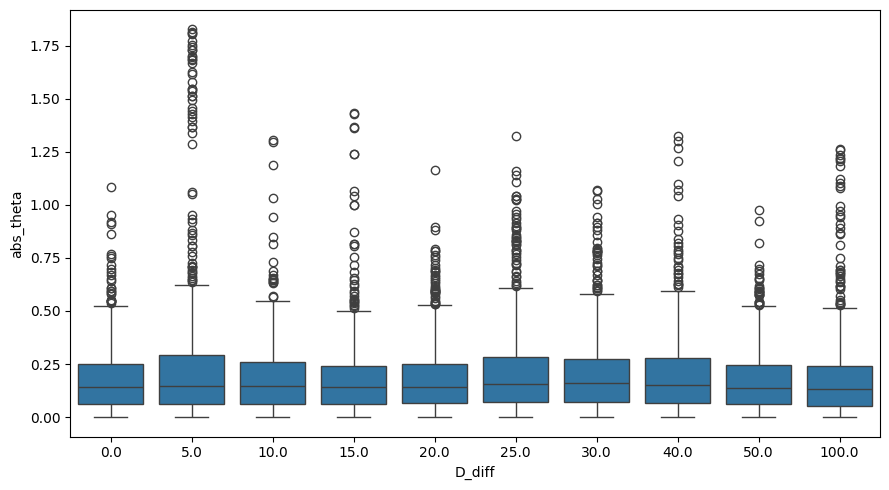

In [69]:
plt.figure(figsize=(9, 5))

df["D_diff"] = df["D_diff"].astype("category")
sns.boxplot(data=df, x="D_diff", y="abs_theta")
plt.tight_layout()

In [70]:
df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

print(summary.to_string(index=False))

D_diff     mean      std
  50.0 0.177450 0.154154
   0.0 0.178775 0.156075
  15.0 0.181820 0.184918
  10.0 0.182349 0.165309
  20.0 0.182947 0.164665
 100.0 0.186209 0.200676
  40.0 0.196834 0.188497
  30.0 0.202465 0.181987
  25.0 0.216742 0.212295
   5.0 0.249255 0.331913


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_9496/3395064099.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_9496/3906487432.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


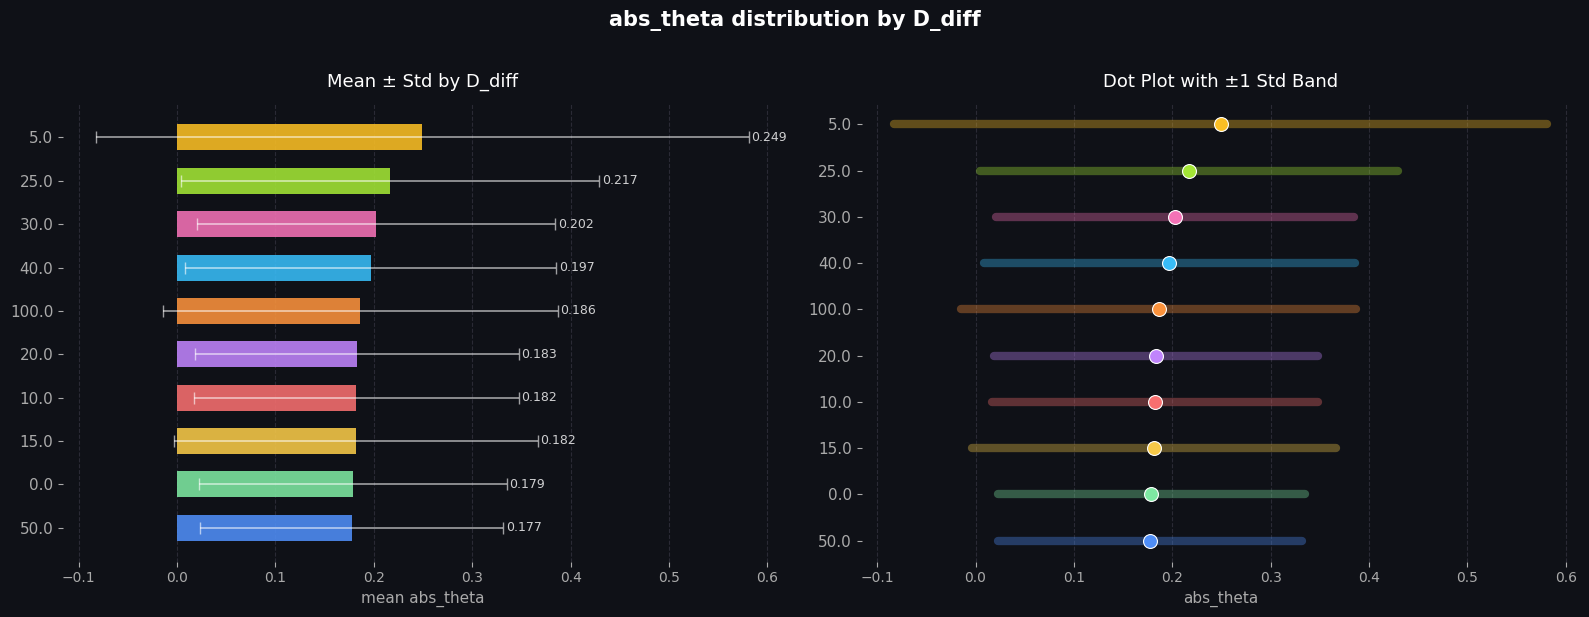

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#0f1117")

PALETTE = ["#4f8ef7", "#7ee8a2", "#f7c948", "#f76f6f", "#c084fc",
           "#fb923c", "#38bdf8", "#f472b6", "#a3e635", "#fbbf24"]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(summary))]

# ── Plot 1: horizontal bar with error bars ──────────────────────────────────
ax1 = axes[0]
y_pos = np.arange(len(summary))
bars = ax1.barh(
    y_pos, summary["mean"],
    xerr=summary["std"],
    color=colors,
    error_kw=dict(ecolor="white", elinewidth=1.2, capsize=4, alpha=0.6),
    height=0.6,
    alpha=0.88,
)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax1.set_xlabel("mean abs_theta", color="#aaaaaa", fontsize=11)
ax1.set_title("Mean ± Std by D_diff", color="white", fontsize=13, pad=12)
ax1.tick_params(colors="#aaaaaa")
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax1.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax1.set_axisbelow(True)

for bar, mean_val, std_val in zip(bars, summary["mean"], summary["std"]):
    ax1.text(
        bar.get_width() + std_val + (summary["mean"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{mean_val:.3f}",
        va="center", ha="left", color="white", fontsize=9, alpha=0.8,
    )

# ── Plot 2: dot plot with std shading ────────────────────────────────────────
ax2 = axes[1]
for i, (_, row) in enumerate(summary.iterrows()):
    ax2.plot([row["mean"] - row["std"], row["mean"] + row["std"]],
             [i, i], color=colors[i], alpha=0.35, linewidth=6, solid_capstyle="round")
    ax2.scatter(row["mean"], i, color=colors[i], s=100, zorder=5, edgecolors="white", linewidths=0.8)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax2.set_xlabel("abs_theta", color="#aaaaaa", fontsize=11)
ax2.set_title("Dot Plot with ±1 Std Band", color="white", fontsize=13, pad=12)
ax2.tick_params(colors="#aaaaaa")
ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax2.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax2.set_axisbelow(True)

plt.suptitle("abs_theta distribution by D_diff", color="white", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("abs_theta_by_D_diff.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()